In [57]:
#!pip install -r requirements.txt

In [58]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, transforms
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter


In [59]:
def create_dataloaders(train_dataset, test_dataset, batch_size, val_split=0.2):
    # Split train_dataset into training and validation datasets
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Extract labels for the training subset
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]

    # Calculate class counts and weights
    class_counts = np.bincount(train_labels)  # Assumes labels are sequential integers starting from 0
    class_weights = 1. / np.sqrt(class_counts + 1e-6)  # Avoid division by zero
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    # Log class weights for debugging
    print(f"Class counts: {class_counts}")
    print(f"Class weights: {class_weights}")

    # Create sample weights for WeightedRandomSampler
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    # Create DataLoaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, sampler=sampler)  # Stratified sampling for training
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)  # No sampling for validation
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)  # Random shuffle for test

    # Log dataset sizes for verification
    print(f"Train size: {len(train_subset)}, Validation size: {len(val_subset)}, Test size: {len(test_dataset)}")

    return train_loader, val_loader, test_loader


In [60]:
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy()

    images = images * 0.5 + 0.5

    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()


In [61]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=100, print_every=100, patience=5):
    """
    Trains a given model with early stopping and logs metrics to TensorBoard.

    Args:
        model: The model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        optimizer: Optimizer for training (e.g., Adam, SGD).
        criterion: Loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        print_every: Frequency (in batches) to print training loss.
        patience: Number of epochs to wait for validation loss improvement before stopping.
    """
    # Initialize TensorBoard writer
    writer = SummaryWriter(log_dir="./logs")

    # Set device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            # Move data to GPU (if available)
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()

            # Log batch loss to TensorBoard
            if (i + 1) % print_every == 0:
                avg_loss = running_loss / print_every
                writer.add_scalar("Training Loss", avg_loss, epoch * len(train_loader) + i)
                running_loss = 0.0

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        # Log validation loss to TensorBoard
        writer.add_scalar("Validation Loss", val_loss, epoch)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    # Close TensorBoard writer
    writer.close()


In [62]:
def evaluate_model(model, data_loader):

    # Set the device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to the device
    model = model.to(device)

    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            # Move data to the same device as model
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [63]:
class CNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [64]:
# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: /home/omarhammad/.cache/kagglehub/datasets/subhaditya/fer2013plus/versions/1


In [65]:

data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomCrop(48, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"
test_dir = path + "/fer2013plus/fer2013/test"
# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])


print(f"Train dataset size : {len(train_dataset)}")
print(f"Test dataset size : {len(test_dataset)}")


Train dataset size : 28386
Test dataset size : 7099


In [66]:
train_loader, val_loader, test_loader = create_dataloaders(train_dataset, test_dataset, 16)
# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Class counts: [1986  130  155  528 6032 8254 2803 2820]
Class weights: tensor([0.0224, 0.0877, 0.0803, 0.0435, 0.0129, 0.0110, 0.0189, 0.0188])
Train size: 22708, Validation size: 5678, Test size: 7099
Image batch shape: torch.Size([16, 1, 48, 48])
Labels batch shape: torch.Size([16])
Labels: tensor([7, 7, 0, 5, 4, 5, 7, 3, 7, 5, 6, 3, 1, 4, 4, 3])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


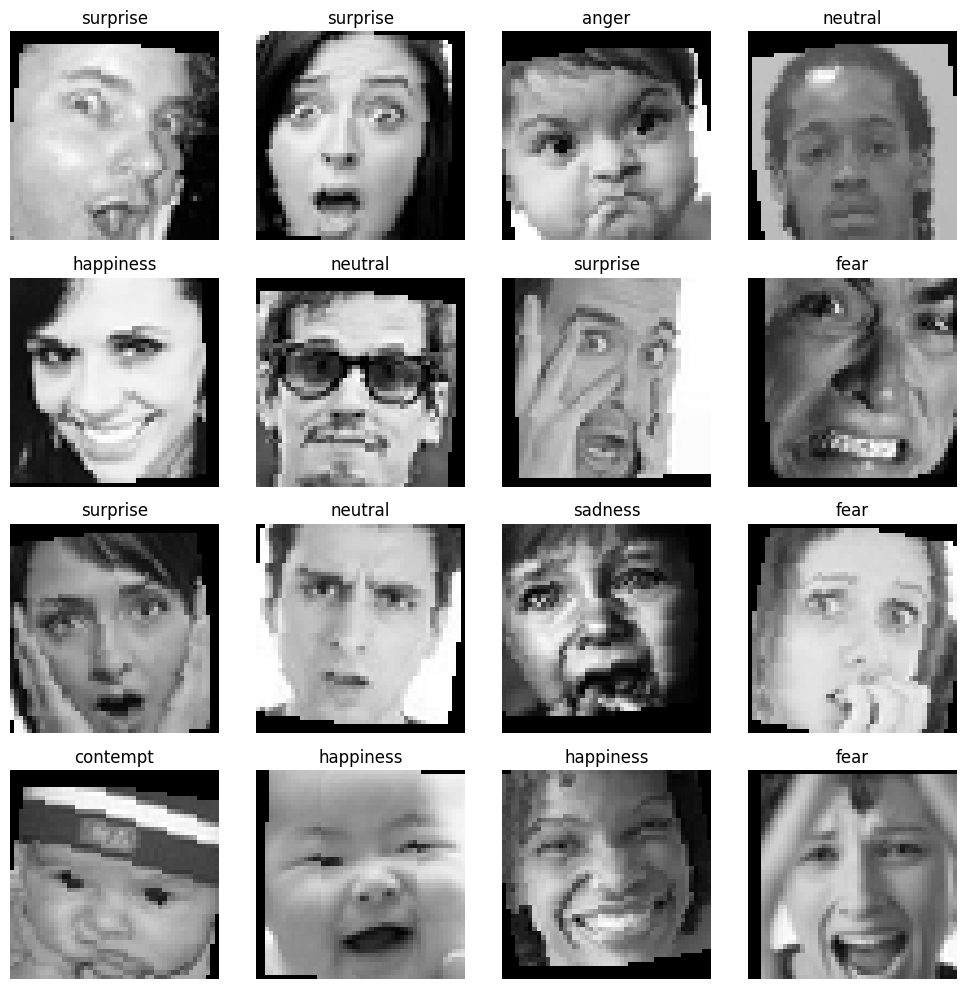

In [67]:
plot_image_batch(images, labels, class_names)


In [68]:
cnn_model = CNN()
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [69]:
train_model(cnn_model, train_loader, val_loader, optimizer, criterion, num_epochs=100, patience=4)

Epoch [1/100], Validation Loss: 1.4689
Epoch [2/100], Validation Loss: 1.2071
Epoch [3/100], Validation Loss: 1.0992
Epoch [4/100], Validation Loss: 1.0237
Epoch [5/100], Validation Loss: 0.9713
Epoch [6/100], Validation Loss: 0.9284
Epoch [7/100], Validation Loss: 0.9072
Epoch [8/100], Validation Loss: 0.8989
Epoch [9/100], Validation Loss: 0.8933
Epoch [10/100], Validation Loss: 0.8876
Epoch [11/100], Validation Loss: 0.8698
Epoch [12/100], Validation Loss: 0.9142
Epoch [13/100], Validation Loss: 0.8911
Epoch [14/100], Validation Loss: 0.8804
Epoch [15/100], Validation Loss: 0.8657
Epoch [16/100], Validation Loss: 0.8952
Epoch [17/100], Validation Loss: 0.9181
Epoch [18/100], Validation Loss: 0.8693
Epoch [19/100], Validation Loss: 0.8215
Epoch [20/100], Validation Loss: 0.8459
Epoch [21/100], Validation Loss: 0.8555
Epoch [22/100], Validation Loss: 0.8384
Epoch [23/100], Validation Loss: 0.8321
Early stopping triggered at epoch 23


In [70]:
train_accuracy = evaluate_model(cnn_model, train_loader)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.7222


In [71]:
test_accuracy = evaluate_model(cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7186


In [72]:
torch.save(cnn_model.state_dict(), 'initial_cnn_model.pth')